In [38]:

!pip install -q datasets nltk spacy gensim sentence-transformers faiss-cpu wordcloud scikit-learn
!python -m spacy download en_core_web_sm -q

print('All dependencies installed successfully!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 28.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed successfully!


#Load Dataset from HuggingFace

In [39]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# Load FABSA dataset
print('Loading jordiclive/FABSA dataset from HuggingFace...')
dataset = load_dataset('jordiclive/FABSA', trust_remote_code=True)
print(f'Dataset structure: {dataset}')

# Convert to DataFrame — use train split
df = pd.DataFrame(dataset['train'])
print(f'\n Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'jordiclive/FABSA' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'jordiclive/FABSA' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading jordiclive/FABSA dataset from HuggingFace...
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 7930
    })
    validation: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1057
    })
    test: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1587
    })
})

 Dataset loaded successfully!
Shape: (7930, 7)
Columns: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes']


,id,org_index,data_source,industry,text,labels,label_codes
0,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,"[[Staff support: Attitude of staff, negative],...","['staff-support.attitude-of-staff.-1', 'compan..."
1,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it ...","[[Company brand: General satisfaction, positiv...","['company-brand.general-satisfaction.1', 'comp..."
2,301980653,369,Google Play,Ride Hailing,Sometimes it takes,"[[Company brand: General satisfaction, negative]]",['company-brand.general-satisfaction.-1']
3,301979991,727,Apple Store,Fashion,This is the worst app I ordered my sneakers 2/...,"[[Logistics rides: Speed, negative], [Online e...","['logistics-rides.speed.-1', 'online-experienc..."
4,301984330,549,Google Play,Travel Booking,So easy & loads of info !,"[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']
5,301979193,616,Apple Store,Fashion,Not all reviews are showing. When it says: thi...,"[[Company brand: Reviews, negative], [Online e...","['company-brand.reviews.-1', 'online-experienc..."
6,301972213,600,Trustpilot,Price Comparison,very easy to use site and got best deal,"[[Purchase booking experience: Ease of use, po...","['purchase-booking-experience.ease-of-use.1', ..."
7,301984266,549,Google Play,Travel Booking,"Very useful, especially when you want to try n...","[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']
8,301988812,727,Google Play,Fashion,"Great service, easy returns, friendly people.","[[Staff support: Attitude of staff, positive],...","['staff-support.attitude-of-staff.1', 'purchas..."
9,301983615,411,Google Play,Groceries,great app well done,"[[Online experience: App website, positive]]",['online-experience.app-website.1']


#Dataset Exploration

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total records    : {len(df)}')
print(f'Total columns    : {len(df.columns)}')
print(f'\nColumn types:')
print(df.dtypes)
print(f'\nNull values:')
print(df.isnull().sum())

# Identify the text column (flexible for any schema)
text_col = None
for col in ['text', 'review', 'comment', 'sentence', 'content', 'body']:
    if col in df.columns:
        text_col = col
        break
if text_col is None:
    text_col = df.select_dtypes(include='object').columns[0]

print(f"\n Using text column: '{text_col}'")

# Sample texts
print('\nSample texts:')
for i, txt in enumerate(df[text_col].dropna().head(5)):
    print(f'  [{i+1}] {str(txt)[:120]}...')

DATASET OVERVIEW
Total records    : 7930
Total columns    : 7

Column types:
id              int64
org_index       int64
data_source    object
industry       object
text           object
labels         object
label_codes    object
dtype: object

Null values:
id             0
org_index      0
data_source    0
industry       0
text           0
labels         0
label_codes    0
dtype: int64

 Using text column: 'text'

Sample texts:
  [1] My experience is only around the Parking forum, so my review is based on this specific experience. As someone who needed...
  [2] I love it so handy, plus I hate my bank so it takes away alot of business from them...
  [3] Sometimes it takes...
  [4] This is the worst app I ordered my sneakers 2/1/2 weeks ago still haven’t received them they saying they attempted to se...
  [5] So easy & loads of info !...


---
## Step 1: Text Cleaning

In [41]:
import re
import string

def clean_text(text):
    """
    Comprehensive text cleaning pipeline:
    - Remove NaN / None
    - Lowercase
    - Remove URLs
    - Remove HTML tags
    - Remove email addresses
    - Remove special characters & punctuation
    - Remove numbers
    - Remove extra whitespace
    """
    if not isinstance(text, str):
        return ''

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters (keep alphabets & spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['cleaned_text'] = df[text_col].apply(clean_text)

# Remove empty rows after cleaning
df = df[df['cleaned_text'].str.len() > 5].reset_index(drop=True)

print('Text cleaning completed!')
print(f'Records after cleaning: {len(df)}')
print('\nBefore vs After Cleaning (sample):')
print('-' * 80)
for i in range(3):
    print(f"ORIGINAL : {str(df[text_col].iloc[i])[:100]}")
    print(f"CLEANED  : {df['cleaned_text'].iloc[i][:100]}")
    print('-' * 80)

Text cleaning completed!
Records after cleaning: 7858

Before vs After Cleaning (sample):
--------------------------------------------------------------------------------
ORIGINAL : My experience is only around the Parking forum, so my review is based on this specific experience. A
CLEANED  : my experience is only around the parking forum so my review is based on this specific experience as 
--------------------------------------------------------------------------------
ORIGINAL : I love it so handy, plus I hate my bank so it takes away alot of business from them
CLEANED  : i love it so handy plus i hate my bank so it takes away alot of business from them
--------------------------------------------------------------------------------
ORIGINAL : Sometimes it takes
CLEANED  : sometimes it takes
--------------------------------------------------------------------------------


---
## Step 2:  Tokenization

In [42]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize, sent_tokenize

# Word tokenization
df['word_tokens'] = df['cleaned_text'].apply(word_tokenize)

# Sentence tokenization (on original text for context)
df['sent_tokens'] = df[text_col].apply(
    lambda x: sent_tokenize(str(x)) if isinstance(x, str) else []
)

# Token statistics
df['token_count'] = df['word_tokens'].apply(len)

print(' Tokenization completed!')
print(f'\nToken count statistics:')
print(df['token_count'].describe().round(2))

print('\nSample tokenized output:')
for i in range(3):
    print(f"\nText    : {df['cleaned_text'].iloc[i][:80]}...")
    print(f"Tokens  : {df['word_tokens'].iloc[i][:15]}")
    print(f"Sentences: {df['sent_tokens'].iloc[i][:2]}")

 Tokenization completed!

Token count statistics:
count    7858.00
mean       21.06
std        29.03
min         1.00
25%         6.00
50%        12.00
75%        24.00
max       495.00
Name: token_count, dtype: float64

Sample tokenized output:

Text    : my experience is only around the parking forum so my review is based on this spe...
Tokens  : ['my', 'experience', 'is', 'only', 'around', 'the', 'parking', 'forum', 'so', 'my', 'review', 'is', 'based', 'on', 'this']
Sentences: ['My experience is only around the Parking forum, so my review is based on this specific experience.', 'As someone who needed information on pursuing actions around an unfair parking fine it was pretty good to read, although there are plenty of other very good forums and sites out there too.']

Text    : i love it so handy plus i hate my bank so it takes away alot of business from th...
Tokens  : ['i', 'love', 'it', 'so', 'handy', 'plus', 'i', 'hate', 'my', 'bank', 'so', 'it', 'takes', 'away', 'alot']
Sentence

---
## Step 3:  Stopword Removal

In [43]:
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Add domain-specific stopwords for media/review context
custom_stopwords = {'would', 'could', 'also', 'get', 'one', 'two', 'said', 'say', 'like', 'make'}
stop_words.update(custom_stopwords)

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words and len(token) > 2]

df['filtered_tokens'] = df['word_tokens'].apply(remove_stopwords)
df['filtered_count'] = df['filtered_tokens'].apply(len)

# Reduction stats
avg_before = df['token_count'].mean()
avg_after = df['filtered_count'].mean()
reduction = (1 - avg_after / avg_before) * 100

print(' Stopword removal completed!')
print(f'\nStopwords in NLTK corpus : {len(stop_words)}')
print(f'Average tokens BEFORE    : {avg_before:.1f}')
print(f'Average tokens AFTER     : {avg_after:.1f}')
print(f'Average reduction        : {reduction:.1f}%')

print('\nSample before vs after stopword removal:')
for i in range(2):
    print(f"\n  Before: {df['word_tokens'].iloc[i][:12]}")
    print(f"  After : {df['filtered_tokens'].iloc[i][:12]}")

 Stopword removal completed!

Stopwords in NLTK corpus : 208
Average tokens BEFORE    : 21.1
Average tokens AFTER     : 10.3
Average reduction        : 51.0%

Sample before vs after stopword removal:

  Before: ['my', 'experience', 'is', 'only', 'around', 'the', 'parking', 'forum', 'so', 'my', 'review', 'is']
  After : ['experience', 'around', 'parking', 'forum', 'review', 'based', 'specific', 'experience', 'someone', 'needed', 'information', 'pursuing']

  Before: ['i', 'love', 'it', 'so', 'handy', 'plus', 'i', 'hate', 'my', 'bank', 'so', 'it']
  After : ['love', 'handy', 'plus', 'hate', 'bank', 'takes', 'away', 'alot', 'business']


---
## Step 4: Lemmatization

In [44]:
import spacy

# Load SpaCy English model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print('Running lemmatization (this may take a moment)...')

# Process with SpaCy pipe for efficiency
texts_to_lemmatize = [' '.join(tokens) for tokens in df['filtered_tokens']]
lemmatized_results = []

batch_size = 500
for i in range(0, len(texts_to_lemmatize), batch_size):
    batch = texts_to_lemmatize[i:i+batch_size]
    for doc in nlp.pipe(batch, batch_size=100):
        lemmatized_results.append([
            token.lemma_ for token in doc
            if token.lemma_.strip() and len(token.lemma_) > 1
        ])

df['lemmatized_tokens'] = lemmatized_results
df['lemma_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

print('Lemmatization completed!')
print('\nLemmatization examples (token → lemma):')
print('-' * 50)

# Show individual token lemmatization examples
sample_tokens = ['running', 'better', 'wolves', 'studying', 'flies', 'went', 'happily']
sample_doc = nlp(' '.join(sample_tokens))
for token in sample_doc:
    print(f'  {token.text:<15} → {token.lemma_}')

print('\nSample lemmatized output:')
for i in range(2):
    print(f"\n  Filtered  : {df['filtered_tokens'].iloc[i][:10]}")
    print(f"  Lemmatized: {df['lemmatized_tokens'].iloc[i][:10]}")

Running lemmatization (this may take a moment)...
Lemmatization completed!

Lemmatization examples (token → lemma):
--------------------------------------------------
  running         → run
  better          → well
  wolves          → wolf
  studying        → study
  flies           → fly
  went            → go
  happily         → happily

Sample lemmatized output:

  Filtered  : ['experience', 'around', 'parking', 'forum', 'review', 'based', 'specific', 'experience', 'someone', 'needed']
  Lemmatized: ['experience', 'around', 'parking', 'forum', 'review', 'base', 'specific', 'experience', 'someone', 'need']

  Filtered  : ['love', 'handy', 'plus', 'hate', 'bank', 'takes', 'away', 'alot', 'business']
  Lemmatized: ['love', 'handy', 'plus', 'hate', 'bank', 'take', 'away', 'alot', 'business']


---
## Step 5: Vocabulary Creation

In [45]:
from collections import Counter

# Flatten all lemmatized tokens
all_tokens = [token for tokens in df['lemmatized_tokens'] for token in tokens]

# Token frequency distribution
token_freq = Counter(all_tokens)

# Build vocabulary with frequency threshold
MIN_FREQ = 2
vocabulary = {word: freq for word, freq in token_freq.items() if freq >= MIN_FREQ}
vocab_sorted = sorted(vocabulary.items(), key=lambda x: x[1], reverse=True)

# Word-to-index mapping
word2idx = {word: idx for idx, (word, _) in enumerate(vocab_sorted)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(' Vocabulary created!')
print('=' * 50)
print(f'Total unique tokens          : {len(token_freq):,}')
print(f'Vocabulary size (freq >= {MIN_FREQ})  : {len(vocabulary):,}')
print(f'Total token occurrences      : {sum(token_freq.values()):,}')
print(f'\nTop 30 most frequent words:')
print('-' * 40)
max_freq = vocab_sorted[0][1] if vocab_sorted else 1
for word, freq in vocab_sorted[:30]:
    bar = '█' * min(int(freq / max_freq * 30), 30)
    print(f'  {word:<20} {freq:>5}  {bar}')

print(f'\nRarest words (freq = {MIN_FREQ}):')
rare_words = [w for w, f in token_freq.items() if f == MIN_FREQ][:10]
print(f'  {rare_words}')

 Vocabulary created!
Total unique tokens          : 6,116
Vocabulary size (freq >= 2)  : 3,180
Total token occurrences      : 81,278

Top 30 most frequent words:
----------------------------------------
  app                   2475  ██████████████████████████████
  org                   2051  ████████████████████████
  use                   1687  ████████████████████
  easy                  1528  ██████████████████
  good                  1278  ███████████████
  great                 1054  ████████████
  service                709  ████████
  time                   707  ████████
  love                   607  ███████
  order                  582  ███████
  well                   545  ██████
  find                   458  █████
  work                   440  █████
  thank                  435  █████
  account                434  █████
  card                   420  █████
  money                  412  ████
  customer               411  ████
  always                 372  ████
  get           

---
## Step 6:Bag of Words & TF-IDF Vectors

In [46]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import scipy.sparse as sp

# Use lemmatized text
corpus = df['lemma_text'].tolist()

# ---- Bag of Words ----
print('Building Bag of Words model...')
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)  # Unigrams + Bigrams
)
bow_matrix = bow_vectorizer.fit_transform(corpus)

# ---- TF-IDF ----
print('Building TF-IDF model...')
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True  # Apply log normalization to TF
)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print('\n Vectorization complete!')
print('=' * 50)
print(f'BoW  matrix shape    : {bow_matrix.shape}')
print(f'TF-IDF matrix shape  : {tfidf_matrix.shape}')
bow_density = bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])
tfidf_density = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
print(f'BoW  matrix density  : {bow_density:.4%}')
print(f'TF-IDF matrix density: {tfidf_density:.4%}')

# Top TF-IDF terms per sample
feature_names = tfidf_vectorizer.get_feature_names_out()
print('\nTop TF-IDF terms for sample documents:')
print('-' * 60)
for i in range(3):
    row = tfidf_matrix[i]
    top_indices = row.toarray()[0].argsort()[::-1][:8]
    top_terms = [(feature_names[j], round(row[0, j], 4)) for j in top_indices if row[0, j] > 0]
    print(f'Doc {i+1}: {top_terms}')

Building Bag of Words model...
Building TF-IDF model...

 Vectorization complete!
BoW  matrix shape    : (7858, 5000)
TF-IDF matrix shape  : (7858, 5000)
BoW  matrix density  : 0.2257%
TF-IDF matrix density: 0.2257%

Top TF-IDF terms for sample documents:
------------------------------------------------------------
Doc 1: [('forum', np.float64(0.2967)), ('regular', np.float64(0.2085)), ('behaviour', np.float64(0.204)), ('come across', np.float64(0.1943)), ('parking', np.float64(0.1943)), ('specific', np.float64(0.1907)), ('across', np.float64(0.1822)), ('member', np.float64(0.1595))]
Doc 2: [('hate', np.float64(0.3991)), ('take away', np.float64(0.383)), ('alot', np.float64(0.383)), ('plus', np.float64(0.3306)), ('handy', np.float64(0.323)), ('business', np.float64(0.3164)), ('away', np.float64(0.2923)), ('bank', np.float64(0.2625))]
Doc 3: [('sometimes take', np.float64(0.7657)), ('sometimes', np.float64(0.5212)), ('take', np.float64(0.3768))]


---
## Step 7:Word Embeddings (Word2Vec via Gensim)

In [47]:
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

# Prepare sentences (list of token lists)
sentences = df['lemmatized_tokens'].tolist()

# Train Word2Vec model
print('Training Word2Vec model...')
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,      # Embedding dimensions
    window=5,             # Context window size
    min_count=2,          # Minimum word frequency
    workers=4,            # Parallel workers
    epochs=15,            # Training epochs
    sg=1,                 # Skip-gram (1) vs CBOW (0)
    negative=5,           # Negative sampling
    seed=42
)

print('Word2Vec model trained!')
print(f'\nModel vocabulary size: {len(w2v_model.wv):,}')
print(f'Embedding dimensions : {w2v_model.vector_size}')

# Explore learned embeddings
print('\n' + '=' * 60)
print('WORD SIMILARITY EXPLORATIONS')
print('=' * 60)

test_words = ['good', 'bad', 'love', 'hate', 'product', 'service', 'quality', 'price', 'great', 'poor']
available_words = [w for w in test_words if w in w2v_model.wv]

if available_words:
    for word in available_words[:4]:
        similar = w2v_model.wv.most_similar(word, topn=6)
        print(f"\nMost similar to '{word}':")
        for sim_word, score in similar:
            print(f'  {sim_word:<20} similarity: {score:.4f}')
else:
    top_words = list(w2v_model.wv.key_to_index.keys())[:4]
    for word in top_words:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nMost similar to '{word}':")
        for sim_word, score in similar:
            print(f'  {sim_word:<20} similarity: {score:.4f}')

Training Word2Vec model...
Word2Vec model trained!

Model vocabulary size: 3,180
Embedding dimensions : 100

WORD SIMILARITY EXPLORATIONS

Most similar to 'good':
  awesome              similarity: 0.7736
  great                similarity: 0.7664
  honest               similarity: 0.7336
  secret               similarity: 0.7334
  consistently         similarity: 0.7227
  exceptional          similarity: 0.7091

Most similar to 'bad':
  dis                  similarity: 0.6624
  disappointed         similarity: 0.6476
  terrible             similarity: 0.6305
  unreliable           similarity: 0.6254
  disgusting           similarity: 0.6149
  worst                similarity: 0.6128

Most similar to 'love':
  toddler              similarity: 0.7921
  convenient           similarity: 0.7896
  favorite             similarity: 0.7844
  enjoyable            similarity: 0.7735
  exclusive            similarity: 0.7718
  flexible             similarity: 0.7669

Most similar to 'hate':
  stock

---
## Step 8: Sentence Embeddings (Sentence-BERT)

In [48]:
from sentence_transformers import SentenceTransformer

# Load lightweight but powerful SBERT model
print('Loading Sentence-BERT model (all-MiniLM-L6-v2)...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Use a subset for efficiency
N_SAMPLES = min(1000, len(df))
sample_df = df.head(N_SAMPLES).copy()
texts_for_embedding = sample_df[text_col].astype(str).tolist()

print(f'Generating sentence embeddings for {N_SAMPLES} documents...')
sentence_embeddings = sbert_model.encode(
    texts_for_embedding,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True  # L2-normalize for cosine similarity via dot product
)

print(f'\n Sentence embeddings generated!')
print(f'Embedding matrix shape   : {sentence_embeddings.shape}')
print(f'Embedding dimension      : {sentence_embeddings.shape[1]}')
print(f'Data type                : {sentence_embeddings.dtype}')

# Cosine similarity sanity check
print('\nCosine Similarity Sanity Check:')
if N_SAMPLES >= 3:
    e1, e2, e3 = sentence_embeddings[0], sentence_embeddings[1], sentence_embeddings[2]
    sim_12 = np.dot(e1, e2)
    sim_13 = np.dot(e1, e3)
    print(f'  Similarity(doc1, doc2): {sim_12:.4f}')
    print(f'  Similarity(doc1, doc3): {sim_13:.4f}')

Loading Sentence-BERT model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating sentence embeddings for 1000 documents...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


 Sentence embeddings generated!
Embedding matrix shape   : (1000, 384)
Embedding dimension      : 384
Data type                : float32

Cosine Similarity Sanity Check:
  Similarity(doc1, doc2): 0.0446
  Similarity(doc1, doc3): 0.0071


---
## Step 9: Similarity Search (FAISS)

In [49]:
import faiss

# Build FAISS index for fast similarity search
embedding_dim = sentence_embeddings.shape[1]  # 384
embeddings_f32 = sentence_embeddings.astype(np.float32)

# Inner Product index (cosine similarity since embeddings are normalized)
index = faiss.IndexFlatIP(embedding_dim)
index.add(embeddings_f32)

print(' FAISS index built!')
print(f'Total vectors indexed: {index.ntotal}')
print(f'Index type           : IndexFlatIP (cosine similarity)')


def semantic_search(query, top_k=5):
    """
    Given a query string, find the top-k most semantically similar
    documents from the indexed corpus using FAISS.
    """
    query_embedding = sbert_model.encode([query], normalize_embeddings=True).astype(np.float32)
    scores, indices = index.search(query_embedding, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            'index': int(idx),
            'score': round(float(score), 4),
            'text' : texts_for_embedding[idx][:200]
        })
    return results


# Run sample queries
test_queries = [
    'excellent product quality and fast delivery',
    'terrible customer service experience',
    'price is too expensive for what you get'
]

for query in test_queries:
    print('\n' + '=' * 70)
    print(f"QUERY: '{query}'")
    print('=' * 70)
    results = semantic_search(query, top_k=4)
    for rank, res in enumerate(results, 1):
        print(f"\nRank {rank} | Score: {res['score']} | Doc #{res['index']}")
        print(f"  {res['text'][:160]}...")

 FAISS index built!
Total vectors indexed: 1000
Index type           : IndexFlatIP (cosine similarity)

QUERY: 'excellent product quality and fast delivery'

Rank 1 | Score: 0.8509 | Doc #120
  Excellent product is satisfied with the delivery...

Rank 2 | Score: 0.7953 | Doc #417
  The quality of things is excellent. Fast delivery. Everything is perfect....

Rank 3 | Score: 0.7931 | Doc #814
  Excellent, fast and efficient delivery!...

Rank 4 | Score: 0.7459 | Doc #367
  Fast delivery and good quality of clothes. Not disappointed, I recommend....

QUERY: 'terrible customer service experience'

Rank 1 | Score: 0.5269 | Doc #8
  Great service, easy returns, friendly people....

Rank 2 | Score: 0.5201 | Doc #379
  Super fashion, good service - bad delivery service (GLS)...

Rank 3 | Score: 0.5189 | Doc #562
  have written to customer service twice and no response in regards discrepancies and questions. no response. not impressed yet....

Rank 4 | Score: 0.499 | Doc #41
  I was treated as

---
## Step 10: Insights & Visualization — Plot 1: Text Statistics

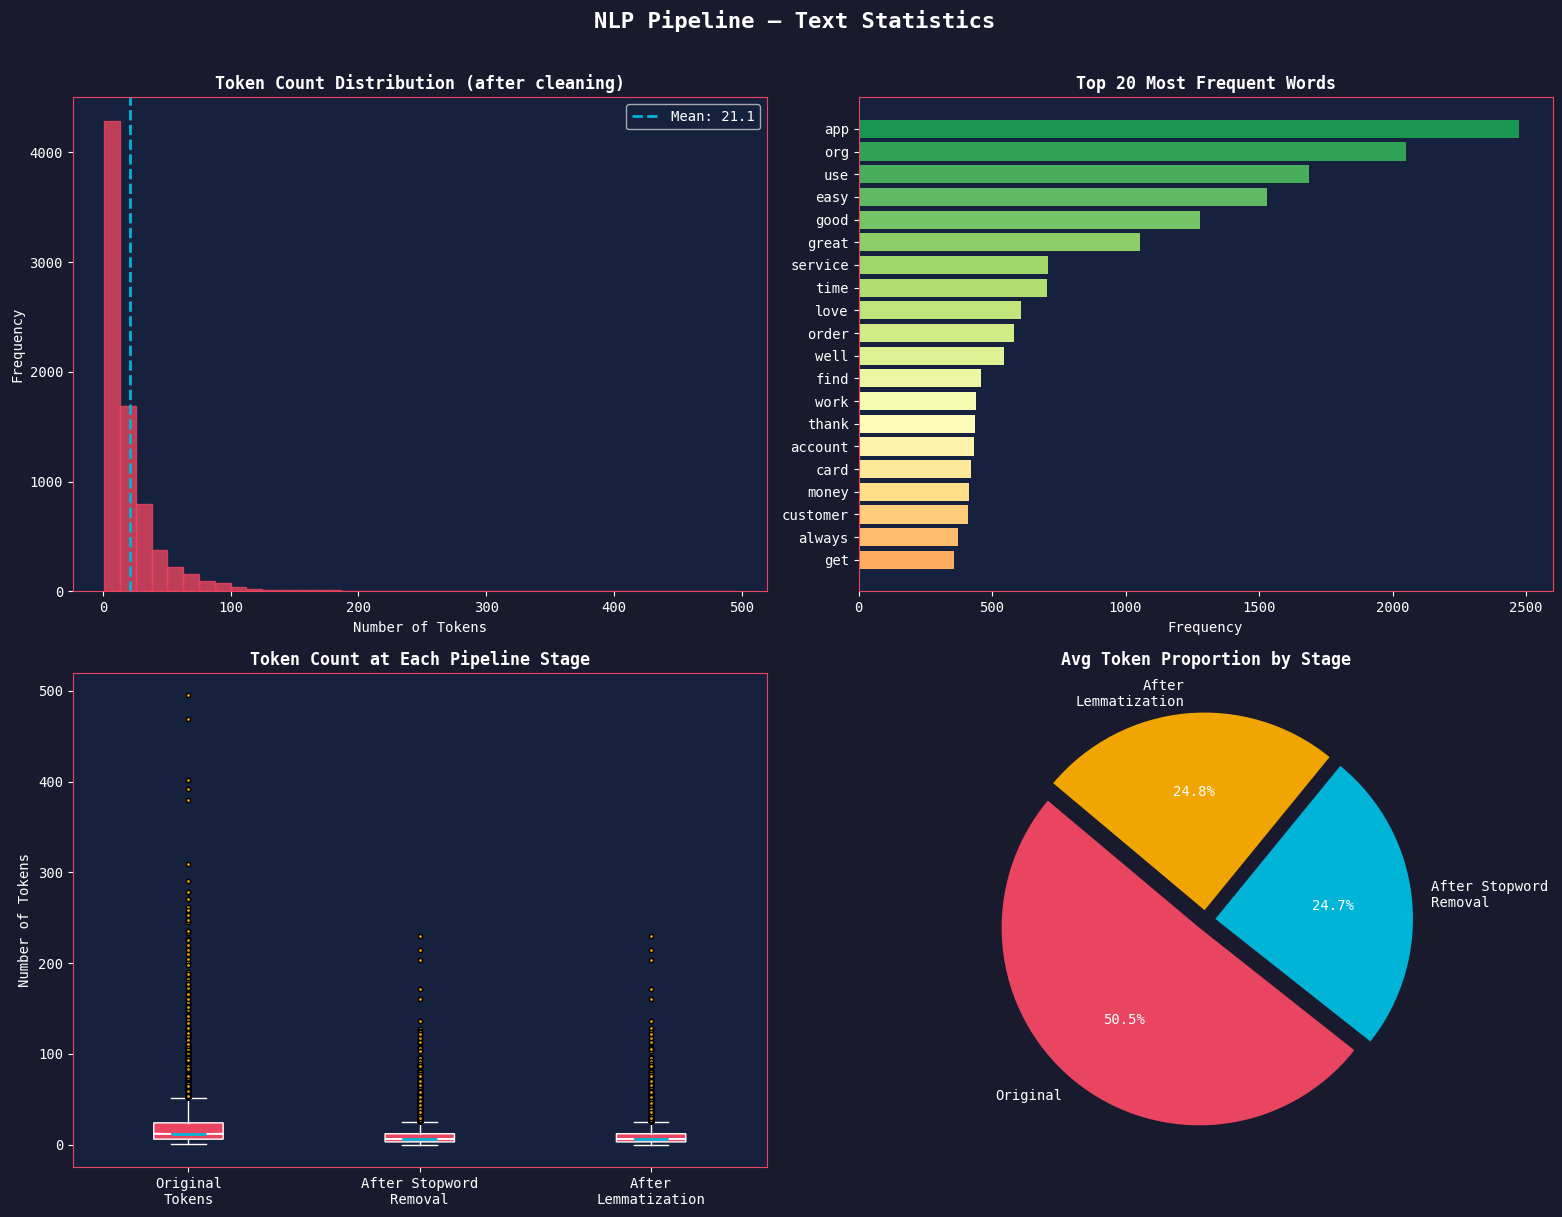

Plot 1: Text Statistics


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e94560',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.5,
    'font.family': 'monospace'
})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('NLP Pipeline — Text Statistics', fontsize=16, fontweight='bold', color='white', y=1.01)

# Plot 1a: Token count histogram
axes[0, 0].hist(df['token_count'], bins=40, color='#e94560', edgecolor='#e94560', alpha=0.8)
axes[0, 0].axvline(df['token_count'].mean(), color='#00b4d8', linestyle='--', linewidth=2,
                   label=f"Mean: {df['token_count'].mean():.1f}")
axes[0, 0].set_title('Token Count Distribution (after cleaning)', fontweight='bold')
axes[0, 0].set_xlabel('Number of Tokens')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Plot 1b: Top 20 most frequent words
top_words_data = vocab_sorted[:20]
words_bar, freqs_bar = zip(*top_words_data)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(words_bar)))
axes[0, 1].barh(list(words_bar)[::-1], list(freqs_bar)[::-1], color=colors)
axes[0, 1].set_title('Top 20 Most Frequent Words', fontweight='bold')
axes[0, 1].set_xlabel('Frequency')

# Plot 1c: Box plot of token counts at each stage
data_to_plot = [df['token_count'].values, df['filtered_count'].values,
                df['lemmatized_tokens'].apply(len).values]
bp = axes[1, 0].boxplot(data_to_plot, patch_artist=True, notch=True,
    boxprops=dict(facecolor='#e94560', color='white'),
    medianprops=dict(color='#00b4d8', linewidth=2),
    whiskerprops=dict(color='white'),
    capprops=dict(color='white'),
    flierprops=dict(markerfacecolor='#f0a500', marker='o', markersize=3))
axes[1, 0].set_xticklabels(['Original\nTokens', 'After Stopword\nRemoval', 'After\nLemmatization'])
axes[1, 0].set_title('Token Count at Each Pipeline Stage', fontweight='bold')
axes[1, 0].set_ylabel('Number of Tokens')

# Plot 1d: Pie chart of average token proportions
stage_means = [
    df['token_count'].mean(),
    df['filtered_count'].mean(),
    df['lemmatized_tokens'].apply(len).mean()
]
labels_pie = ['Original', 'After Stopword\nRemoval', 'After\nLemmatization']
axes[1, 1].pie(stage_means, labels=labels_pie, autopct='%1.1f%%',
               colors=['#e94560', '#00b4d8', '#f0a500'],
               explode=(0.05, 0.05, 0.05), startangle=140,
               textprops={'color': 'white', 'fontsize': 10})
axes[1, 1].set_title('Avg Token Proportion by Stage', fontweight='bold')

plt.tight_layout()
plt.show()
print('Plot 1: Text Statistics')

### Plot 2: Word Cloud

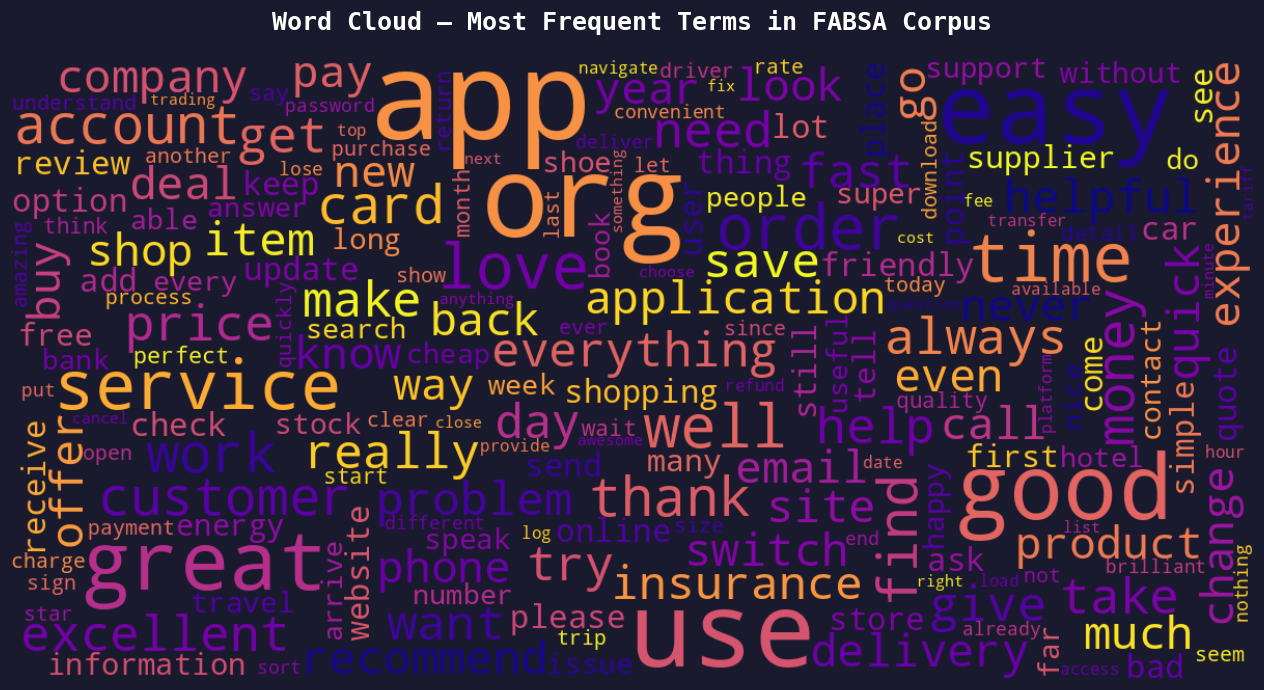

 Plot 2: Word Cloud


In [51]:
from wordcloud import WordCloud

freq_dict = dict(vocab_sorted[:300])

wc = WordCloud(
    width=1200, height=600,
    background_color='#1a1a2e',
    colormap='plasma',
    max_words=200,
    contour_color='#e94560',
    contour_width=2,
    prefer_horizontal=0.8,
    min_font_size=8,
    max_font_size=120,
    random_state=42
).generate_from_frequencies(freq_dict)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Most Frequent Terms in FABSA Corpus',
             fontsize=18, fontweight='bold', color='white', pad=20)
plt.tight_layout()
plt.show()
print(' Plot 2: Word Cloud')

### Plot 3: TF-IDF Heatmap

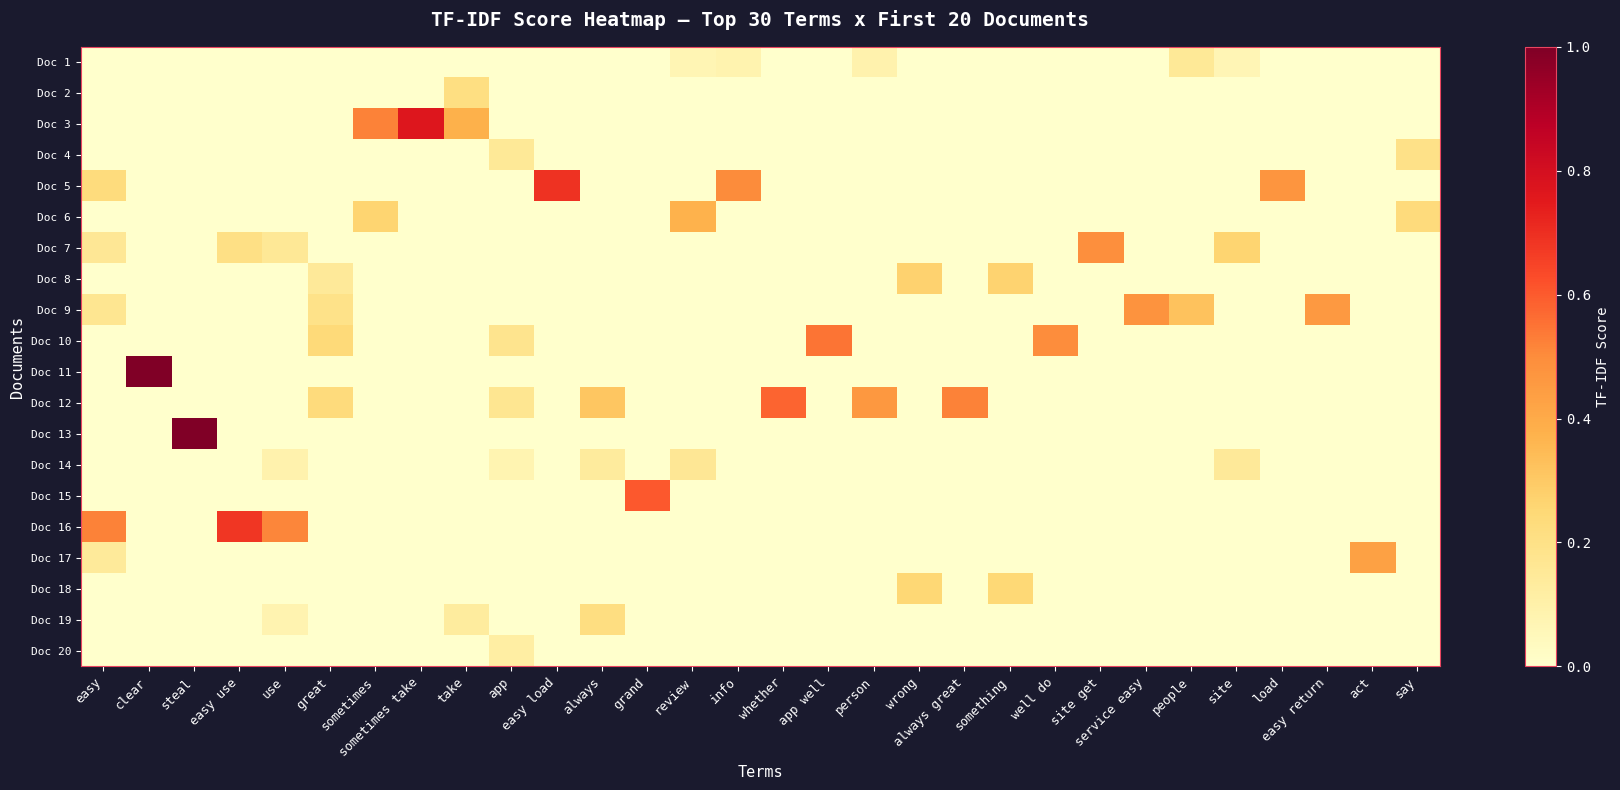

 Plot 3: TF-IDF Heatmap


In [52]:
tfidf_dense = tfidf_matrix[:20].toarray()
top_feature_indices = np.argsort(tfidf_dense.mean(axis=0))[::-1][:30]
top_features = feature_names[top_feature_indices]
heatmap_data = tfidf_dense[:, top_feature_indices]

fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha='right', fontsize=9, color='white')
ax.set_yticks(range(20))
ax.set_yticklabels([f'Doc {i+1}' for i in range(20)], fontsize=8, color='white')
ax.set_title('TF-IDF Score Heatmap — Top 30 Terms x First 20 Documents',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Terms', color='white', fontsize=11)
ax.set_ylabel('Documents', color='white', fontsize=11)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('TF-IDF Score', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.show()
print(' Plot 3: TF-IDF Heatmap')

### Plot 4: Word2Vec PCA Projection

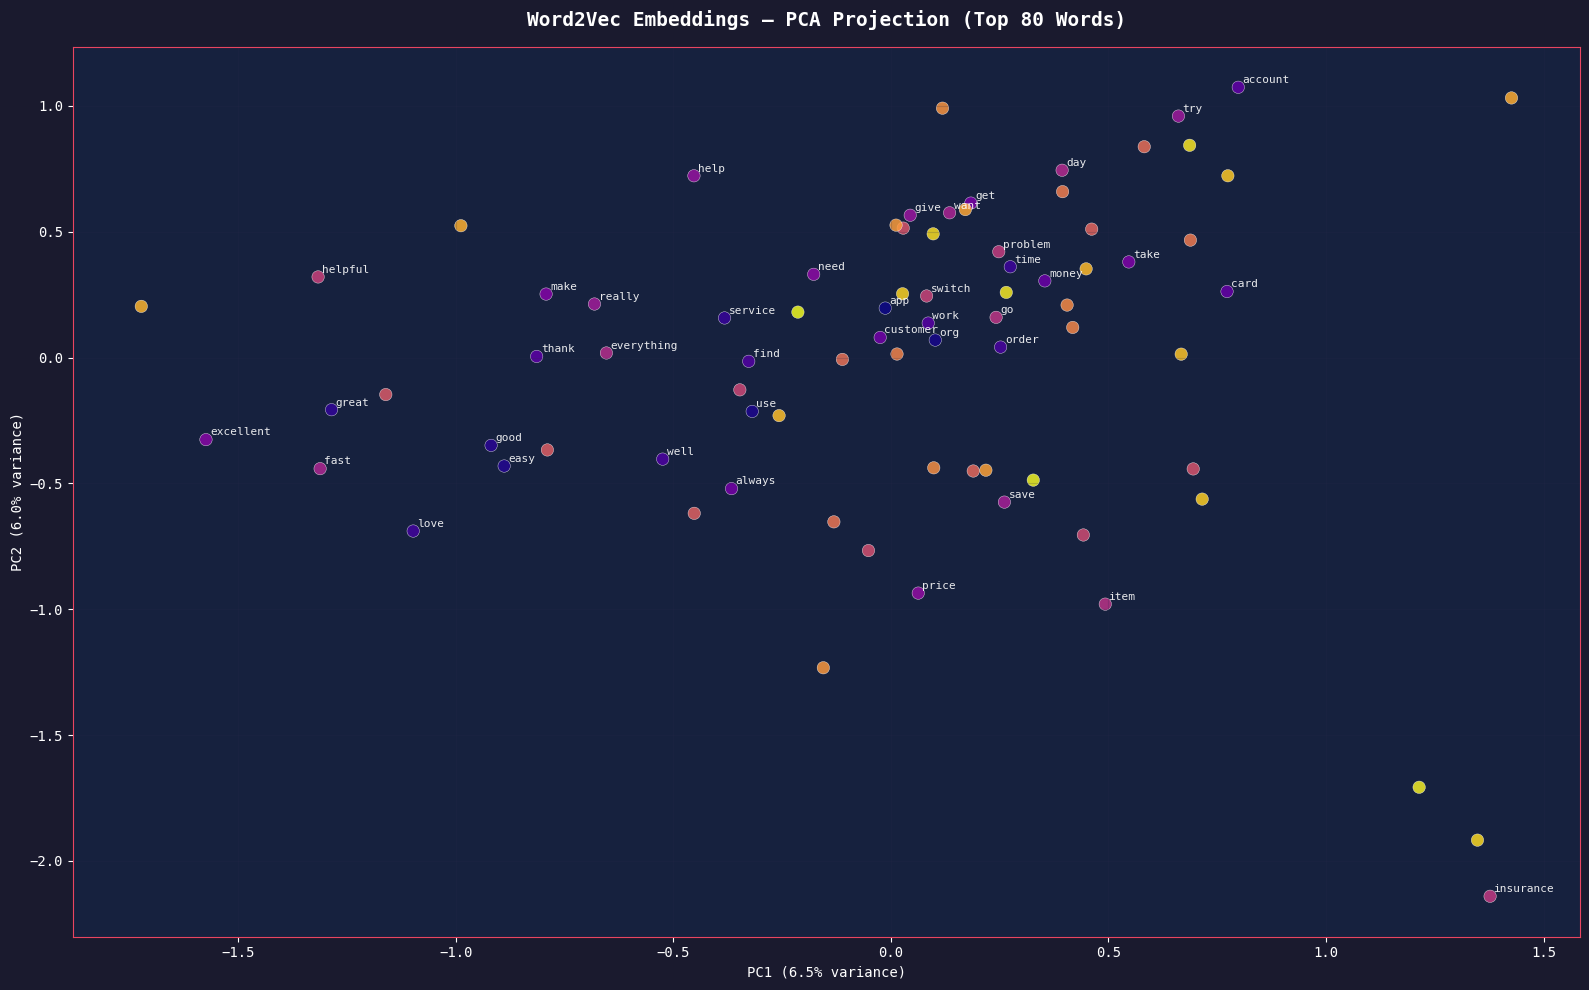

Plot 4: Word2Vec PCA


In [53]:
from sklearn.decomposition import PCA

# Get top 80 words from vocabulary that exist in W2V
top_vocab = [w for w, _ in vocab_sorted if w in w2v_model.wv][:80]
top_vectors = np.array([w2v_model.wv[w] for w in top_vocab])

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(top_vectors)

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

scatter = ax.scatter(reduced[:, 0], reduced[:, 1],
                     c=range(len(top_vocab)), cmap='plasma',
                     s=80, alpha=0.85, edgecolors='white', linewidths=0.3)

# Annotate top 40 words
for i, word in enumerate(top_vocab[:40]):
    ax.annotate(word, (reduced[i, 0], reduced[i, 1]),
                fontsize=8, color='white', alpha=0.9,
                xytext=(3, 3), textcoords='offset points')

ax.set_title(f'Word2Vec Embeddings — PCA Projection (Top {len(top_vocab)} Words)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', color='white')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', color='white')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print('Plot 4: Word2Vec PCA')

### Plot 5: Sentence Embeddings t-SNE Clustering

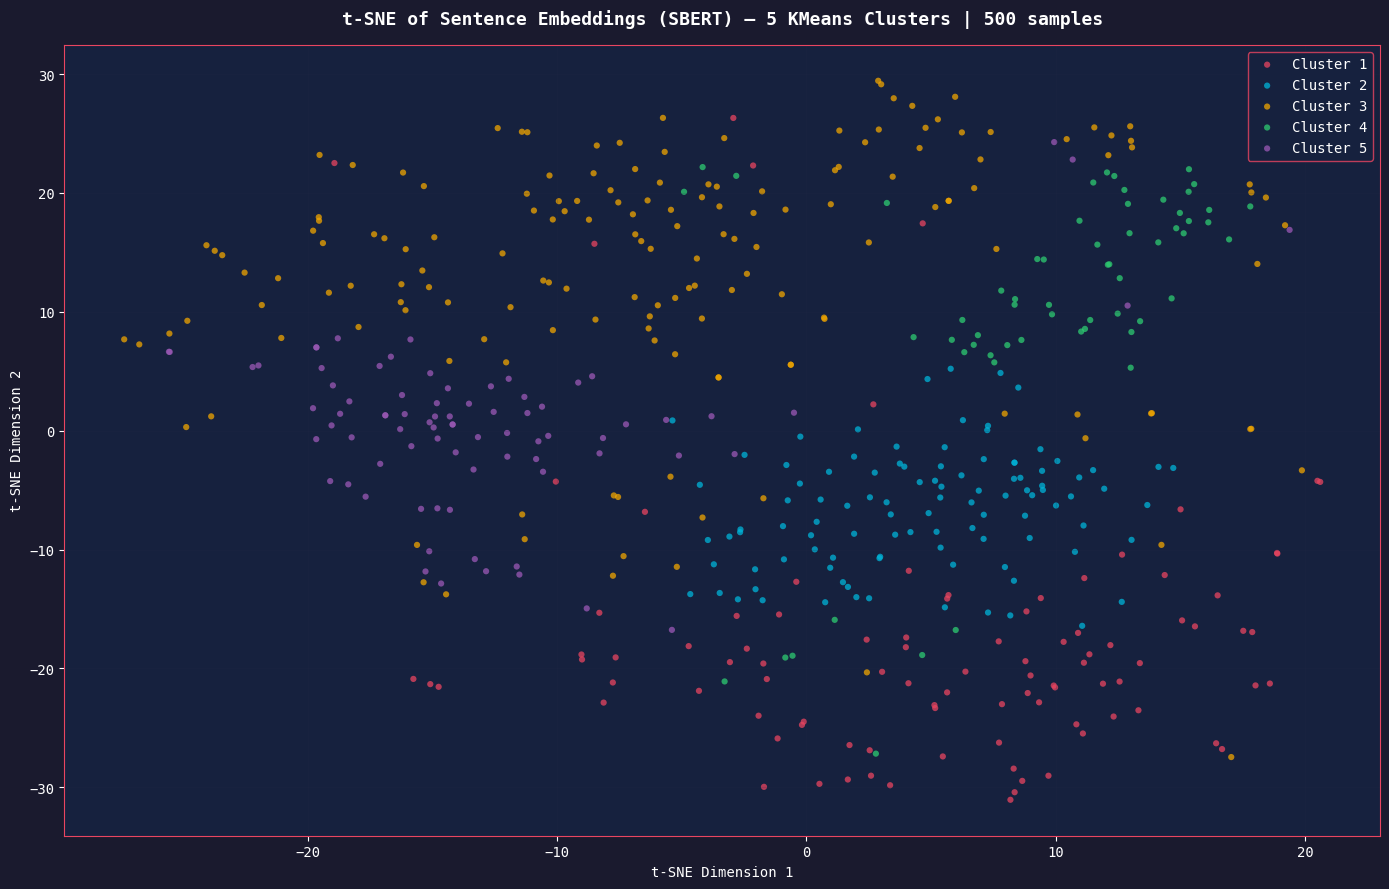

Plot 5: SBERT t-SNE Clustering


In [54]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# Cluster sentence embeddings
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(sentence_embeddings)

# t-SNE for 2D visualization (subset for speed)
TSNE_SAMPLES = min(500, len(sentence_embeddings))
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_coords = tsne.fit_transform(sentence_embeddings[:TSNE_SAMPLES])
cluster_sub = cluster_labels[:TSNE_SAMPLES]

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

colors_tsne = ['#e94560', '#00b4d8', '#f0a500', '#2ecc71', '#9b59b6']
for cluster_id in range(N_CLUSTERS):
    mask = cluster_sub == cluster_id
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               color=colors_tsne[cluster_id], label=f'Cluster {cluster_id + 1}',
               s=20, alpha=0.75, edgecolors='none')

ax.set_title(f't-SNE of Sentence Embeddings (SBERT) — {N_CLUSTERS} KMeans Clusters | {TSNE_SAMPLES} samples',
             fontsize=13, fontweight='bold', color='white', pad=15)
ax.set_xlabel('t-SNE Dimension 1', color='white')
ax.set_ylabel('t-SNE Dimension 2', color='white')
ax.legend(facecolor='#16213e', edgecolor='#e94560', labelcolor='white', fontsize=10)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()
print('Plot 5: SBERT t-SNE Clustering')

### Plot 6: Cosine Similarity Distribution & Zipf's Law

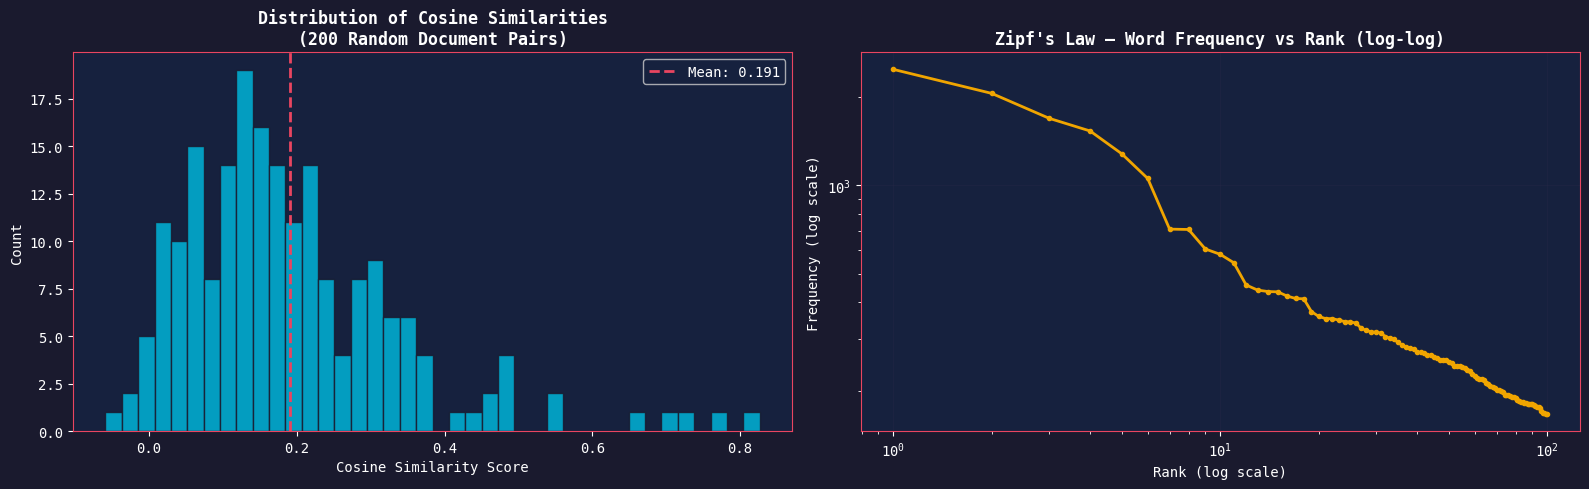

Plot 6: Similarity Distribution + Zipf Law


In [55]:
# Compute pairwise similarity scores for 200 random pairs
np.random.seed(42)
n = min(200, len(sentence_embeddings))
idx_pairs = np.random.choice(n, size=(400, 2), replace=True)
idx_pairs = idx_pairs[idx_pairs[:, 0] != idx_pairs[:, 1]]

cosine_scores = [
    np.dot(sentence_embeddings[i], sentence_embeddings[j])
    for i, j in idx_pairs[:200]
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')

# Histogram of cosine similarities
axes[0].hist(cosine_scores, bins=40, color='#00b4d8', edgecolor='#1a1a2e', alpha=0.85)
axes[0].axvline(np.mean(cosine_scores), color='#e94560', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(cosine_scores):.3f}')
axes[0].set_title('Distribution of Cosine Similarities\n(200 Random Document Pairs)',
                  fontweight='bold', color='white')
axes[0].set_xlabel('Cosine Similarity Score', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].legend(labelcolor='white', facecolor='#16213e')

# Zipf's Law — word frequency vs rank (log-log)
freqs_all = sorted([f for _, f in token_freq.items()], reverse=True)[:100]
ranks = range(1, len(freqs_all) + 1)
axes[1].loglog(list(ranks), freqs_all, color='#f0a500', linewidth=2, marker='o', markersize=3)
axes[1].set_title("Zipf's Law — Word Frequency vs Rank (log-log)",
                  fontweight='bold', color='white')
axes[1].set_xlabel('Rank (log scale)', color='white')
axes[1].set_ylabel('Frequency (log scale)', color='white')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Plot 6: Similarity Distribution + Zipf Law')